In [ ]:
## building the graph
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model


In [14]:
##set the variables
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [15]:
#load the model
llm1 = ChatGroq(model="llama-3.3-70b-versatile") #"llama3-8b-8192")
#or
llm=init_chat_model("groq:llama-3.3-70b-versatile") #here have opt

In [50]:
llm.invoke("hello how are you?").content

"Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? How's your day going so far?"

### BMI calculator workflow

In [47]:
from langgraph.graph import StateGraph, START, END
from typing import Dict,Literal,TypedDict

In [35]:
#define state
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category : str

In [36]:
def calculate_bmi(State: BMIState) -> BMIState:
    weight = State['weight_kg']
    height = State['height_m']

    bmi = weight/(height**2)

    State['bmi'] = round(bmi,2)

    return State



In [37]:
def label_bmi(State: BMIState) -> BMIState:
    bmi =State['bmi']

    if bmi < 18.5:
        State['category'] ="underweight"
    elif 18.5 <= bmi <25:
        State['category'] = "Normal"
    elif 25 <= bmi <30:
        State['category'] = "overweight"
    else:
        State['category'] = "obese"

    return State

In [38]:
#define your graph
graph = StateGraph(BMIState)

##add nodes
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label_bmi', label_bmi)

#add edges
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('label_bmi',END)

#compile graph
workflow = graph.compile()


In [39]:
#execute the workflow
initial_state = {'weight_kg':92,'height_m':1.82}
final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 92, 'height_m': 1.82, 'bmi': 27.77, 'category': 'overweight'}


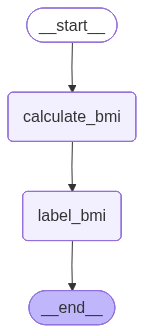

In [40]:
#show the visual represantation of the workflow
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

### LLM QA

In [51]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [52]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")

In [53]:
#create state

class LLMState(TypedDict):
     
     quation : str
     answer : str

In [54]:
def llm_qa(state: LLMState) -> LLMState:

    #get the quation
    quation = state['quation']

    #from a prompt
    prompt = f'Answer the following quation {quation}'

    state['answer'] = llm.invoke(prompt).content

    return state

In [56]:
#crate the graph

graph = StateGraph(LLMState)

#add node
graph.add_node('llm_qa',llm_qa)

#add edges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

#compile
workflow=graph.compile()

In [58]:
#execute
intial_state = {'quation': "How far the moon from the earth?"}
final_state = workflow.invoke(intial_state)
print(final_state['answer'])

The average distance from the Earth to the Moon is approximately 384,400 kilometers (238,900 miles). This distance is constantly changing due to the elliptical shape of the Moon's orbit around the Earth. At its closest point (called perigee), the Moon is about 356,400 kilometers (221,500 miles) away, and at its farthest point (apogee), it is about 405,500 kilometers (252,000 miles) away.


### topic blog genration

In [83]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [84]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")

In [85]:
class BlogState(TypedDict):
    title : str
    outline : str
    content : str
    score : int

In [86]:
def create_outline(state: BlogState) -> BlogState:
    
    #featch title
    title = state['title']

    #call llm gen outline
    prompt = f"Genrate a detail outline for the blog on the topic {title}"
    outline = llm.invoke(prompt).content

    #updating state
    state['outline'] = outline
    
    return state

In [87]:
def create_blog(state: BlogState) -> BlogState:

    #get the info for the outline
    title = state['title']
    outline = state['outline']

    prompt = f"write the detail blog on the title -{title} using following outline \n {outline} "

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

In [88]:
def genrate_score(state : BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']
    content = state['content']

    #promt for the llm
    prompt = f"I create the blog the title - {title} \n Based on the created \n outline : {outline} \n blog : {content} \n please rate out of 10 in genrated content and retrun only integer as output"

    score = llm.invoke(prompt).content
    state['score'] = score

    return state

In [89]:
graph = StateGraph(BlogState)

#crate node
graph.add_node("create_outline",create_outline)
graph.add_node("create_blog",create_blog)
graph.add_node("genrate_score",genrate_score)

#add edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','genrate_score')
graph.add_edge('genrate_score',END)

#compile
workflow = graph.compile()

In [90]:
initial_state = {'title': 'GenrativeAI'}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': 'GenrativeAI', 'outline': 'Here is a detailed outline for a blog on the topic of Generative AI:\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its applications\n* Introduction to Generative AI and its significance\n* Thesis statement: Generative AI is a rapidly growing field that has the potential to revolutionize various industries and transform the way we create and interact with content.\n\n**II. What is Generative AI?**\n\n* Definition of Generative AI and its differences from other types of AI\n* Explanation of the concept of generative models and their applications\n* Overview of the types of Generative AI, including:\n\t+ Generative Adversarial Networks (GANs)\n\t+ Variational Autoencoders (VAEs)\n\t+ Transformers\n\t+ Recurrent Neural Networks (RNNs)\n\n**III. Applications of Generative AI**\n\n* Overview of the various applications of Generative AI, including:\n\t+ Art and design: generating art, music, and other creative content\n\t+ 

In [91]:
print(final_state['score'])

8
